In [1]:
import os
import sys
from dataclasses import dataclass
from typing import Tuple, Optional, Literal

import torch
from torch import nn, Tensor
import torch.nn.functional as F

from model import Linear, MoE, Gate

In [2]:
@dataclass
class DynamicModelArgs:
    dim: int = 64
    moe_inter_dim: int = 44
    n_routed_experts: int = 16
    n_shared_experts: int = 1
    n_activated_experts: int = 8
    n_expert_groups: int = 8
    n_limited_groups: int = 4
    score_func: Literal["softmax", "sigmoid"] = "sigmoid"
    route_scale: float = 1.0

args = DynamicModelArgs()
args

DynamicModelArgs(dim=64, moe_inter_dim=44, n_routed_experts=16, n_shared_experts=1, n_activated_experts=8, n_expert_groups=8, n_limited_groups=4, score_func='sigmoid', route_scale=1.0)

In [3]:
dtype = torch.bfloat16
torch.set_default_dtype(dtype)
torch.set_num_threads(8)
torch.manual_seed(965)

In [4]:
device = "cuda:0"
with torch.device(device):
    moe_layer = MoE(args)

In [5]:
def init_weights_normal(m):
    if isinstance(m, (Linear, Gate)):
        nn.init.normal_(m.weight, mean=0.0, std=0.1)

moe_layer.apply(init_weights_normal);

In [6]:
batch_size = 3
x = torch.randn(batch_size, args.dim, device=device, dtype=dtype)

with torch.inference_mode():
    y = moe_layer(x)
print(y.shape)

torch.Size([3, 64])


In [7]:
y.max(), y.min()

(tensor(1.2578, device='cuda:0'), tensor(-1.0781, device='cuda:0'))

In [8]:
moe_layer.gate.weight

Parameter containing:
tensor([[ 0.0150, -0.0072, -0.2500,  ..., -0.0923, -0.0289, -0.1553],
        [ 0.0444,  0.0192,  0.0527,  ..., -0.0337, -0.0146, -0.0488],
        [ 0.0500, -0.0101, -0.0986,  ..., -0.1572, -0.0205,  0.0942],
        ...,
        [-0.0649, -0.1196, -0.0176,  ...,  0.0737,  0.0913, -0.1260],
        [ 0.1211, -0.1045,  0.1006,  ...,  0.0781, -0.1816, -0.0141],
        [-0.0262, -0.0957,  0.0171,  ..., -0.0515, -0.0728, -0.1104]],
       device='cuda:0', requires_grad=True)

In [9]:
@dataclass
class StaticMoEArgs:
    dim: int = 64
    intermediate_size: int = 342
    num_experts: int = 8
    num_activated_experts: int = 2

class ConditionalFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.w1 = nn.Parameter(torch.empty(config.num_experts, config.intermediate_size, config.dim))
        self.w2 = nn.Parameter(torch.empty(config.num_experts, config.dim, config.intermediate_size))
        self.w3 = nn.Parameter(torch.empty(config.num_experts, config.intermediate_size, config.dim))

    def forward(self, x: Tensor, expert_indices: Tensor) -> Tensor:
        w1_weights = self.w1[expert_indices] # [T, A, D, D]
        w3_weights = self.w3[expert_indices] # [T, A, D, D]
        w2_weights = self.w2[expert_indices]  # [T, A, D, D]
        x1 = F.silu(torch.einsum('ti,taoi -> tao', x, w1_weights))
        x3 = torch.einsum('ti, taoi -> tao', x, w3_weights)
        expert_outs =  torch.einsum('tao, taio -> tai', (x1 * x3), w2_weights)
        return expert_outs


class MOEFeedForward(nn.Module):
    def __init__(self, config) -> None:
        super().__init__()
        self.gate = None  # take from dynamic MoE
        self.shared_experts = None # take from dynamic MoE
        self.cond_ffn = ConditionalFeedForward(config) # overwrite by dynamic MoE
        
        self.dim = config.dim
        self.num_activated_experts = config.num_activated_experts

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        shape = x.size()
        x = x.view(-1, self.dim)
        
        expert_weights, expert_indices = self.gate(x)

        expert_outs = self.cond_ffn(x, expert_indices)
        y = torch.einsum('tai,ta -> ti', expert_outs, expert_weights)
        z = self.shared_experts(x)
        return y + z


def dynamic_moe_to_static(dynamic_args, moe_layer, device=device):
    static_config = StaticMoEArgs(
        num_experts=dynamic_args.n_routed_experts,
        num_activated_experts=dynamic_args.n_activated_experts,
        dim=dynamic_args.dim,
        intermediate_size=dynamic_args.moe_inter_dim
    )
    
    with torch.device(device):
        static_moe_layer = MOEFeedForward(static_config)
    static_moe_layer.gate = moe_layer.gate

    # merge expert list to 3D weight matrix
    # TODO: 
    for i in range(len(moe_layer.experts)):
        assert moe_layer.experts[i].w1.bias is None
        assert moe_layer.experts[i].w2.bias is None
        assert moe_layer.experts[i].w3.bias is None
        static_moe_layer.cond_ffn.w1.data[i] = moe_layer.experts[i].w1.weight.data
        static_moe_layer.cond_ffn.w2.data[i] = moe_layer.experts[i].w2.weight.data
        static_moe_layer.cond_ffn.w3.data[i] = moe_layer.experts[i].w3.weight.data

    static_moe_layer.shared_experts = moe_layer.shared_experts

    return static_moe_layer

In [10]:
static_moe_layer = dynamic_moe_to_static(args, moe_layer)
static_moe_layer

MOEFeedForward(
  (cond_ffn): ConditionalFeedForward()
  (gate): Gate()
  (shared_experts): MLP(
    (w1): ColumnParallelLinear()
    (w2): RowParallelLinear()
    (w3): ColumnParallelLinear()
  )
)

In [11]:
with torch.inference_mode():
    y_static = static_moe_layer(x)

In [12]:
y_static.shape

torch.Size([3, 64])

In [13]:
y_static.max(), y_static.min()

(tensor(1.2578, device='cuda:0'), tensor(-1.0781, device='cuda:0'))

In [14]:
torch.allclose(y_static, y, rtol=1e-2, atol=1e-3)

True

In [15]:
torch.mean(torch.abs(y_static - y))

tensor(0.0003, device='cuda:0')

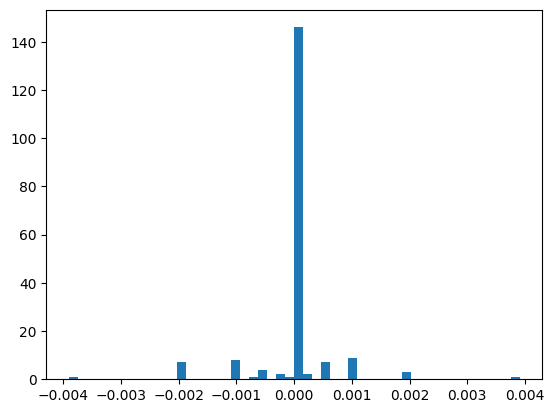

In [16]:
import matplotlib.pyplot as plt
plt.hist((y_static - y).to(torch.float32).cpu().flatten(), bins=50);

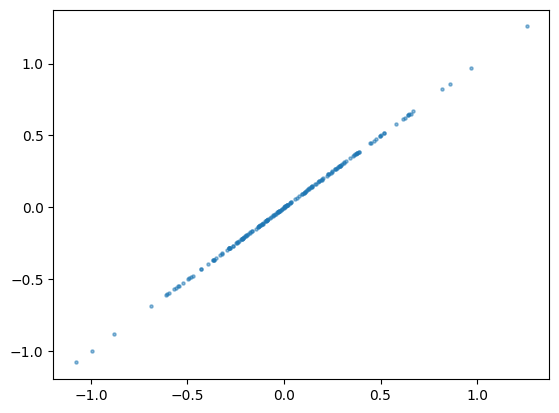

In [17]:
plt.scatter(
    y_static.to(torch.float32).cpu(),
    y.to(torch.float32).cpu(),
    s=5, alpha=0.5
)